In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
data=pd.read_csv(r"C:\Users\faizp\Downloads\New folder (2)\Crop Prediction Dataset (U).csv")

In [4]:
data

,Record_ID,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield,Production_per_Area,Rainfall_Category,Fertilizer_per_Area,Pesticide_per_Area,Yield_Category,Year_Group
0,1,Arecanut,1997,Whole Year,Assam,73814.0,56708.0,2051.4,7024878.38,22882.34,0.796087,0.768255,High,95.17,0.31,Low,1997-2000
1,2,Arhar/Tur,1997,Kharif,Assam,6637.0,4685.0,2051.4,631643.29,2057.47,0.710435,0.705891,High,95.17,0.31,Low,1997-2000
2,3,Castor seed,1997,Kharif,Assam,NaN,22.0,2051.4,75755.32,246.76,0.238333,0.027638,High,95.17,0.31,Low,1997-2000
3,4,Coconut,1997,Whole Year,Assam,19656.0,126905000.0,2051.4,1870661.52,6093.36,NaN,6456.298331,High,95.17,0.31,Very High,1997-2000
4,5,Cotton(lint),1997,Kharif,Assam,1739.0,794.0,2051.4,165500.63,539.09,0.420909,0.456584,High,95.17,0.31,Low,1997-2000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19684,19685,Small millets,1998,Kharif,Nagaland,4000.0,2000.0,1498.0,395200.00,1160.00,0.500000,0.500000,Medium,98.80,0.29,Low,1997-2000
19685,19686,Wheat,1998,Rabi,Nagaland,1000.0,3000.0,1498.0,98800.00,290.00,3.000000,3.000000,Medium,98.80,0.29,Medium,1997-2000
19686,19687,Maize,1997,Kharif,Jammu and Kashmir,310883.0,440900.0,1356.2,29586735.11,96373.73,1.285000,1.418218,Medium,95.17,0.31,Medium,1997-2000
19687,19688,Rice,1997,Kharif,Jammu and Kashmir,275746.0,5488.0,1356.2,26242746.82,85481.26,0.016667,0.019902,Medium,95.17,0.31,Low,1997-2000


# 1. Identify how many columns contain null values, and for each such column, determine the total number of null values..

In [5]:
data.isnull().sum()

Record_ID                 0
Crop                      0
Crop_Year                 0
Season                    0
State                     0
Area                   1378
Production             1378
Annual_Rainfall         110
Fertilizer              563
Pesticide                 0
Yield                  1181
Production_per_Area    1575
Rainfall_Category         0
Fertilizer_per_Area       0
Pesticide_per_Area        0
Yield_Category            0
Year_Group                0
dtype: int64

# 2. Check whether the columns Area and Production contain any null values. If null values are present, first examine whether these columns contain outliers. If outliers exist, fill the null values using an appropriate technique. Ensure that no decimal values are allowed in the Area column.

Area

In [6]:
Q1=data["Area"].quantile(0.25)
Q3=data["Area"].quantile(0.75)
area=Q3-Q1

In [7]:
lower_area= Q1-1.5*area
upper_area= Q3+1.5*area

In [8]:
outliner=data[(data["Area"]<lower_area)|(data["Area"]<upper_area)]

In [9]:
len(outliner)

15449

In [10]:
data["Area"]=data["Area"].fillna(data["Area"].median())

In [11]:
data["Area"]=data["Area"].round().astype(int)

Production

In [12]:
Q1=data["Production"].quantile(0.25)
Q3=data["Production"].quantile(0.75)
area=Q3-Q1

In [13]:
lower_area= Q1-1.5*area
upper_area= Q3+1.5*area

In [14]:
outliner=data[(data["Production"]<lower_area)|(data["Production"]<upper_area)]

In [15]:
len(outliner)

15165

In [16]:
data["Production"]=data["Production"].fillna(data["Production"].median())

# 3. It has been observed that the missing values in the Annual_Rainfall column follow an average rainfall pattern. Fill the missing values using the average rainfall of the column. Ensure that the final values are stored as integers (no decimal values allowed).

In [17]:
avg_rainfall=data["Annual_Rainfall"].mean()

In [18]:
data["Annual_Rainfall"]=data["Annual_Rainfall"].fillna(avg_rainfall)

In [19]:
data["Annual_Rainfall"]=data["Annual_Rainfall"].round().astype(int)

# 4. Determine the maximum and minimum values in the Fertilizer column. Calculate the average of these two values and use this average to fill all missing values. Ensure that the filled values contain at least two decimal places.

In [20]:
max=data["Fertilizer"].max()

In [21]:
min=data["Fertilizer"].min()

In [22]:
avg=(max-min)/2

In [23]:
data["Fertilizer"]=data["Fertilizer"].fillna(avg)

# 5. Analyze whether the Yield column contains outliers. If outliers are present or not, handle the missing values using an appropriate technique and justify your approach


In [24]:
Q1=data["Yield"].quantile(0.25)
Q3=data["Yield"].quantile(0.75)
area=Q3-Q1

In [25]:
lower_area= Q1-1.5*area
upper_area= Q3+1.5*area

In [26]:
outliner=data[(data["Yield"]<lower_area)|(data["Yield"]<upper_area)]

In [27]:
len(outliner)

15697

In [28]:
data["Yield"]=data["Yield"].fillna(data["Yield"].median())

# 6. The Production_per_Area column contains missing values due to data collection gaps.

# 7. Impute the missing values in the Production_per_Area column using a forward fill strategy and store the updated values back in the same column.

In [29]:
data["Production_per_Area"]=data["Production_per_Area"].fillna(method="ffill")

# 8. After completing all the data cleaning, preprocessing, and transformation steps on both datasets (Crop_Production and Climate_Agriculture), split the final cleaned dataset into two separate CSV files and export them according to the following specifications:

In [30]:
Crop_Production=data[["Record_ID","Crop_Year","Season","State","Area","Production","Yield","Production_per_Area","Yield_Category","Crop"]]

In [31]:
Crop_Production.to_csv("Crop_Production.csv",index=False)

In [32]:
Climate_Agriculture=data[["Record_ID","Annual_Rainfall","Rainfall_Category","Fertilizer","Fertilizer_per_Area","Pesticide","Pesticide_per_Area","Year_Group"]]

In [33]:
Climate_Agriculture.to_csv("Climate_Agriculture.csv",index=False)

# ML

# Q1. Load the cleaned Crop Yield dataset. Identify the Type of ML Problem. Select 'Yield_category' as target variable.print the shape of X and y.

In [34]:
x=data.drop("Yield_Category",axis=1)
y=data["Yield_Category"]

# Q2.Identify categorical and Numeric columns. Apply Encoding techniques (if necessary).perform Standard Scaling on numerical features. Display the final processed data.

In [35]:
from sklearn.preprocessing import LabelEncoder,StandardScaler

In [63]:
le = LabelEncoder()
categorical_cols = data.select_dtypes(include=['object']).columns

In [64]:
for col in categorical_cols:
    data[col] = le.fit_transform(data[col].astype(str))

In [65]:
numerical_cols = data.select_dtypes(include=['int64', 'float64']).columns

In [66]:
scaler = StandardScaler()
data[numerical_cols] = scaler.fit_transform(data[numerical_cols])

In [67]:
print(data.dtypes)

Record_ID              float64
Crop                     int32
Crop_Year              float64
Season                   int32
State                    int32
Area                     int32
Production             float64
Annual_Rainfall          int32
Fertilizer             float64
Pesticide              float64
Yield                  float64
Production_per_Area    float64
Rainfall_Category        int32
Fertilizer_per_Area    float64
Pesticide_per_Area     float64
Yield_Category           int32
Year_Group               int32
dtype: object


# Q.3.Plot distribution of the yield_category column. Analyse the relationship between Rainfall and yield_category, Temperature and yield_category, Area and yield_category.

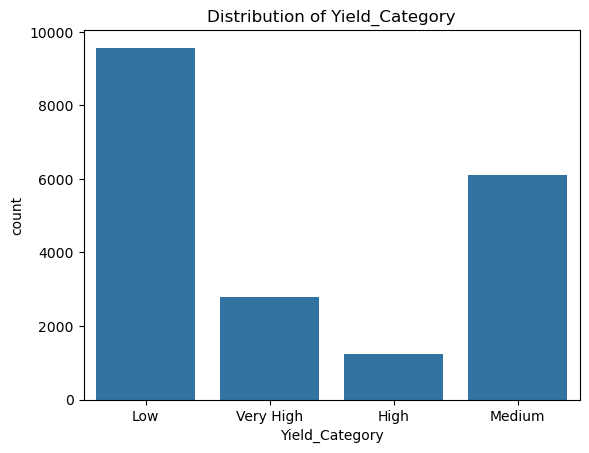

In [37]:
sns.countplot(x="Yield_Category", data=data)
plt.title("Distribution of Yield_Category")
plt.show()

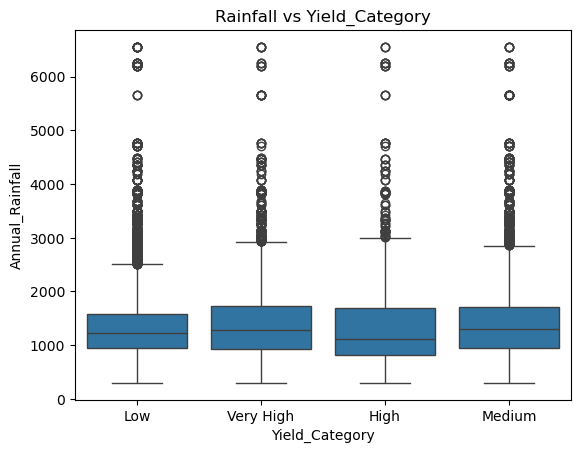

In [38]:
sns.boxplot(x="Yield_Category", y="Annual_Rainfall", data=data)
plt.title("Rainfall vs Yield_Category")
plt.show()

# Q.4 Split the dataset into training and testing sets. Train a KNN model and find best accuracy point by using Elbow method. Display accuracy Score, Confusion Matrix, Classification Report.

In [68]:
from sklearn.model_selection import train_test_split

In [69]:
x_train,x_test,y_train,y_test = train_test_split(x, y,test_size=0.2,random_state=42)

In [70]:
from sklearn.neighbors import KNeighborsClassifier

In [71]:
model=KNeighborsClassifier()

In [72]:
model.fit(x_train,y_train)

KNeighborsClassifier()

In [74]:
model.score(x_train,y_train)

0.8068694051171355

In [75]:
model.score(x_test,y_test)

0.7158456069070595

In [76]:
y_test

18238         High
6918        Medium
4894     Very High
10960          Low
15615          Low
           ...    
8087     Very High
14720          Low
9234        Medium
19610          Low
1692           Low
Name: Yield_Category, Length: 3938, dtype: object

In [77]:
yp=model.predict(x_test)

In [78]:
yp

array(['Low', 'Low', 'High', ..., 'Medium', 'Medium', 'Low'], dtype=object)

In [73]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [79]:
accuracy_score(y_test,yp)

0.7158456069070595

In [80]:
c= confusion_matrix(y_test,yp)

In [82]:
c

array([[  78,   42,  102,   20],
       [  10, 1655,  240,   11],
       [  31,  516,  674,   11],
       [  31,   70,   35,  412]], dtype=int64)

In [81]:
print(classification_report(yp,y_test))

              precision    recall  f1-score   support

        High       0.32      0.52      0.40       150
         Low       0.86      0.72      0.79      2283
      Medium       0.55      0.64      0.59      1051
   Very High       0.75      0.91      0.82       454

    accuracy                           0.72      3938
   macro avg       0.62      0.70      0.65      3938
weighted avg       0.75      0.72      0.72      3938



In [84]:
from sklearn.ensemble import RandomForestClassifier

In [85]:
model = RandomForestClassifier()

In [86]:
model.fit(x_train,y_train)

RandomForestClassifier()

In [87]:
yp=model.predict(x_test)

In [88]:
yp

array(['High', 'Medium', 'Very High', ..., 'Medium', 'Low', 'Low'],
      dtype=object)

In [89]:
accuracy_score(y_test,yp)

0.9911122397155917

In [90]:
c= confusion_matrix(y_test,yp)

In [92]:
c

array([[ 229,    0,   12,    1],
       [   0, 1906,    9,    1],
       [   2,    0, 1228,    2],
       [   3,    0,    5,  540]], dtype=int64)

In [91]:
print(classification_report(yp,y_test))

              precision    recall  f1-score   support

        High       0.95      0.98      0.96       234
         Low       0.99      1.00      1.00      1906
      Medium       1.00      0.98      0.99      1254
   Very High       0.99      0.99      0.99       544

    accuracy                           0.99      3938
   macro avg       0.98      0.99      0.98      3938
weighted avg       0.99      0.99      0.99      3938

